In [5]:
import pandas as pd
import matplotlib as plt 
import seaborn as sns

print("pandas:",pd.__version__)
print("matplotlib:", plt.__version__)
print("seaborn:", sns.__version__)
print("全部OK！")

pandas: 2.3.3
matplotlib: 3.10.9
seaborn: 0.13.2
全部OK！


In [ ]:
from pybaseball import statcast_batter
df=statcast_batter("2026-03-26","2026-05-25",player_id=660271)
print(f"取得した行数: {len(df)}行")
print(f"取得した列数: {len(df.columns)}列")
print (df.columns.tolist)
print(df["game_type"].value_counts)


Gathering Player Data
取得した行数: 549行
取得した列数: 118列
<bound method IndexOpsMixin.tolist of Index(['pitch_type', 'game_date', 'release_speed', 'release_pos_x',
       'release_pos_z', 'player_name', 'batter', 'pitcher', 'events',
       'description',
       ...
       'batter_days_until_next_game', 'api_break_z_with_gravity',
       'api_break_x_arm', 'api_break_x_batter_in', 'arm_angle', 'attack_angle',
       'attack_direction', 'swing_path_tilt',
       'intercept_ball_minus_batter_pos_x_inches',
       'intercept_ball_minus_batter_pos_y_inches'],
      dtype='object', length=118)>


In [ ]:
print (df.columns.tolist)
print(df["game_type"].value_counts)

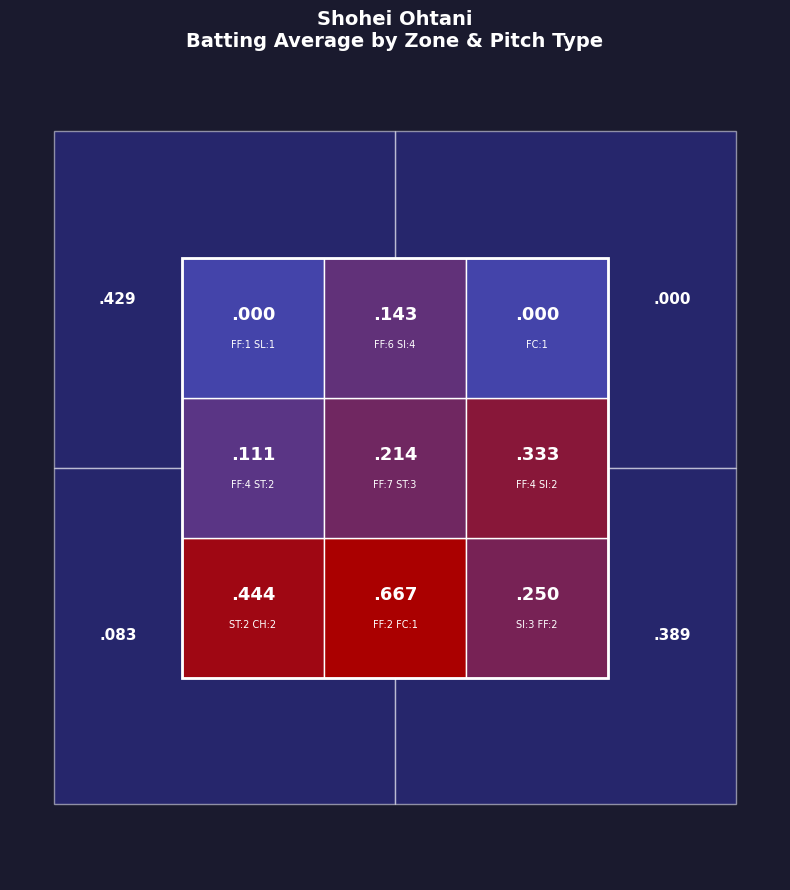

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap

# レギュラーシーズンのみに絞る
regular_season = df[df['game_date'] >= '2026-03-26']

# 打数の定義（四球・死球・犠打を除く）
non_ab_events = [
    'walk',
    'hit_by_pitch',
    'sac_fly',
    'sac_bunt',
]

at_bats = regular_season[
    regular_season['events'].notna() &
    ~regular_season['events'].isin(non_ab_events)
].dropna(subset=['zone'])

# ヒットの定義
hit_events = ['single', 'double', 'triple', 'home_run']

# カラーマップ（青→赤）
cmap = LinearSegmentedColormap.from_list('ba', ['#4444aa', '#aa0000'])

# ゾーンの境界
sz_top = 0.83
sz_bot = -0.83
x_left = -0.83
x_right = 0.83
zone_width = x_right - x_left
zone_height = sz_top - sz_bot

# 内側9マスの境界
x_thirds = [
    x_left,
    x_left + zone_width / 3,
    x_left + zone_width * 2 / 3,
    x_right
]
z_thirds = [
    sz_bot,
    sz_bot + zone_height / 3,
    sz_bot + zone_height * 2 / 3,
    sz_top
]

# 外側エリアの広さ
outer_w = 0.5
outer_h = 0.5

# 中点
x_mid = (x_left + x_right) / 2
z_mid = (sz_bot + sz_top) / 2

def calc_zone_by_id(zone_ids):
    """zone番号でデータを抽出して打率を計算する"""
    mask = at_bats['zone'].isin(zone_ids)
    zone_ab = at_bats[mask]
    total = len(zone_ab)
    hits_count = zone_ab['events'].isin(hit_events).sum()
    ba = hits_count / total if total > 0 else 0
    pitch_counts = zone_ab['pitch_type'].value_counts().head(2)
    return ba, total, pitch_counts

def draw_zone(x_min, x_max, z_min, z_max, ba,
              is_inner=True, show_pitch=False, pitch_counts=None):
    """内側9マスを描画する"""
    color = cmap(ba / 0.5) if ba > 0 else '#4444aa'

    rect = patches.Rectangle(
        (x_min, z_min),
        x_max - x_min,
        z_max - z_min,
        linewidth=1,
        edgecolor='white',
        facecolor=color,
        alpha=1.0
    )
    ax.add_patch(rect)

    cx = (x_min + x_max) / 2
    cz = (z_min + z_max) / 2

    ax.text(cx, cz + (0.05 if show_pitch else 0),
            f'.{round(ba*1000):03d}',
            ha='center', va='center',
            fontsize=13,
            fontweight='bold',
            color='white')

    if show_pitch and pitch_counts is not None and len(pitch_counts) > 0:
        pitch_text = ' '.join([f'{p}:{n}'
                               for p, n in pitch_counts.items()])
        ax.text(cx, cz - 0.07, pitch_text,
                ha='center', va='center',
                fontsize=7, color='white')

def draw_l_shape(vertices, ba, text_pos):
    """L字形をPathで一発描画"""
    codes = ([Path.MOVETO] +
             [Path.LINETO] * (len(vertices) - 2) +
             [Path.CLOSEPOLY])
    path = Path(vertices, codes)
    patch = PathPatch(path,
                      facecolor='#3333aa',
                      edgecolor='white',
                      linewidth=1,
                      alpha=0.5)
    ax.add_patch(patch)
    tx, tz = text_pos
    ax.text(tx, tz, f'.{round(ba*1000):03d}',
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='white')

fig, ax = plt.subplots(figsize=(8, 9))

# ① 内側9マス（zone 1〜9）
zone_grid = [
    [7, 8, 9],   # row_idx=0（下）
    [4, 5, 6],   # row_idx=1（中）
    [1, 2, 3],   # row_idx=2（上）
]

for row_idx in range(3):
    for col_idx in range(3):
        zone_id = zone_grid[row_idx][col_idx]
        x_min = x_thirds[col_idx]
        x_max = x_thirds[col_idx + 1]
        z_min = z_thirds[row_idx]
        z_max = z_thirds[row_idx + 1]

        ba, total, pitch_counts = calc_zone_by_id([zone_id])
        draw_zone(x_min, x_max, z_min, z_max,
                  ba, is_inner=True,
                  show_pitch=True,
                  pitch_counts=pitch_counts)

# ② zone 11：右上L字
ba, _, _ = calc_zone_by_id([11])
draw_l_shape([
    (x_mid,             sz_top),
    (x_mid,             sz_top + outer_h),
    (x_right + outer_w, sz_top + outer_h),
    (x_right + outer_w, z_mid),
    (x_right,           z_mid),
    (x_right,           sz_top),
    (x_mid,             sz_top),
], ba, text_pos=(x_right + outer_w/2,
                 (z_mid + sz_top + outer_h)/2))

# ③ zone 12：左上L字
ba, _, _ = calc_zone_by_id([12])
draw_l_shape([
    (x_left - outer_w, z_mid),
    (x_left - outer_w, sz_top + outer_h),
    (x_mid,            sz_top + outer_h),
    (x_mid,            sz_top),
    (x_left,           sz_top),
    (x_left,           z_mid),
    (x_left - outer_w, z_mid),
], ba, text_pos=(x_left - outer_w/2,
                 (z_mid + sz_top + outer_h)/2))

# ④ zone 13：左下L字
ba, _, _ = calc_zone_by_id([13])
draw_l_shape([
    (x_left - outer_w, sz_bot - outer_h),
    (x_left - outer_w, z_mid),
    (x_left,           z_mid),
    (x_left,           sz_bot),
    (x_mid,            sz_bot),
    (x_mid,            sz_bot - outer_h),
    (x_left - outer_w, sz_bot - outer_h),
], ba, text_pos=(x_left - outer_w/2,
                 (sz_bot - outer_h + z_mid)/2))

# ⑤ zone 14：右下L字
ba, _, _ = calc_zone_by_id([14])
draw_l_shape([
    (x_mid,             sz_bot - outer_h),
    (x_mid,             sz_bot),
    (x_right,           sz_bot),
    (x_right,           z_mid),
    (x_right + outer_w, z_mid),
    (x_right + outer_w, sz_bot - outer_h),
    (x_mid,             sz_bot - outer_h),
], ba, text_pos=(x_right + outer_w/2,
                 (sz_bot - outer_h + z_mid)/2))

# ストライクゾーン外枠
outer_rect = patches.Rectangle(
    (x_left, sz_bot),
    zone_width, zone_height,
    linewidth=2, edgecolor='white',
    facecolor='none'
)
ax.add_patch(outer_rect)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(sz_bot - 0.8, sz_top + 0.8)
ax.set_title('Shohei Ohtani\nBatting Average by Zone & Pitch Type',
             fontsize=14, fontweight='bold', color='white')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.axis('off')

plt.tight_layout()
plt.show()